# 32회 ADP 복원 

In [3]:
#라이브러리 로드
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 기계학습 (60점)

## 데이터 설명
- 데이터 출처 : https://www.kaggle.com/datasets/csafrit2/steel-industry-energy-consumption?resource=download 후처리
- 데이터 링크 : ./data/32/adp32_p1.csv
- 데이터 설명 : 시간대별 발전량에 대한 데이터이다


## 전처리 규칙
- 파생변수 ind11칼럼의 값이 1인 데이터만 훈련에 사용할 것, ind22칼럼의 값이 1인 데이터만 테스트에 사용할 것
- 모든 모델링은 그리드서치를 통해서 최적 파라미터를 산출할 것 (각 모델의 파라미터는 3개 이하로)

In [3]:
import pandas as pd 
df = pd.read_csv("./data/32/adp32_p1.csv")
df.head()

,date,Kwh,LaCR,LeCR,co2,LaF,LeF
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0


## 1-1  date 컬럼을 이용하여 3개의 파생변수를 만들어라
- 1. month : 해당 시각의 월 정보
- 2. day : 해당 시각의 일자 정보, 일요일-0, 월요일-1 ~ 토요일-6
- 3. nsd : 해당 시각의 일자의 자정으로부터 소요된 총 분(minute)

In [44]:
df['date'] = pd.to_datetime(df['date'],format = '%d/%m/%Y %H:%M')
df['month'] = df['date'].dt.month
df['day'] = (df['date'].dt.day_of_week +1) % 7
df['nsd'] = df['date'].dt.minute + df['date'].dt.hour * 60
display(df.head())
print('month','day','nsd','를 추가했다')

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75,1,0


month day nsd 를 추가했다


## 1-2 아래 기준으로 두개의 파생변수를 추가하라
- 파생변수명(ind11) : month, day, nsd 컬럼의 합이 11의 배수이고 22의 배수가 아니라면 1의 값 그 외는 0의 값
- 파생변수명(ind22) : month, day, nsd 컬럼의 합이 22의 배수라면 1의 값 그 외는 0의 값

In [45]:
df['ind11'] = (((df['month'] + df['day'] + df['nsd']) % 11 ==0) & ((df['month'] + df['day'] + df['nsd']) % 22 != 0)).astype('int')
df['ind22'] = ((df['month'] + df['day'] + df['nsd']) % 22 ==0).astype('int')
display(df.head())
print('ind11과 ind22를 추가했다.')
pd.crosstab(df['ind11'],df['ind22'])

,date,Kwh,LaCR,LeCR,co2,LaF,LeF,month,day,nsd,ind11,ind22
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,1,1,15,0,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1,1,30,0,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,1,1,45,0,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,1,1,60,0,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,1,1,75,1,0


ind11과 ind22를 추가했다.


ind22,0,1
ind11,,
0,31858,1583
1,1599,0


## 1-3 아래 기준으로 한개의 파생변수를 추가하라
- 파생변수명(Kwh8) : Kwh컬럼의 값이 4.1 초과일 경우 1 그 외 0

In [49]:
df['Kwh8'] = df['Kwh'].map(lambda x : 1 if x >4.1 else 0)
df['khw]= mpa']
display(df['Kwh8'].value_counts().to_frame())
print('Kwh8의 분포는 위와 같다')

,Kwh8
1,18815
0,16225


Kwh8의 분포는 위와 같다


## 1-4 전처리 완료한 데이터를 기준으로 EDA를 실시하라 (시각화 포함)

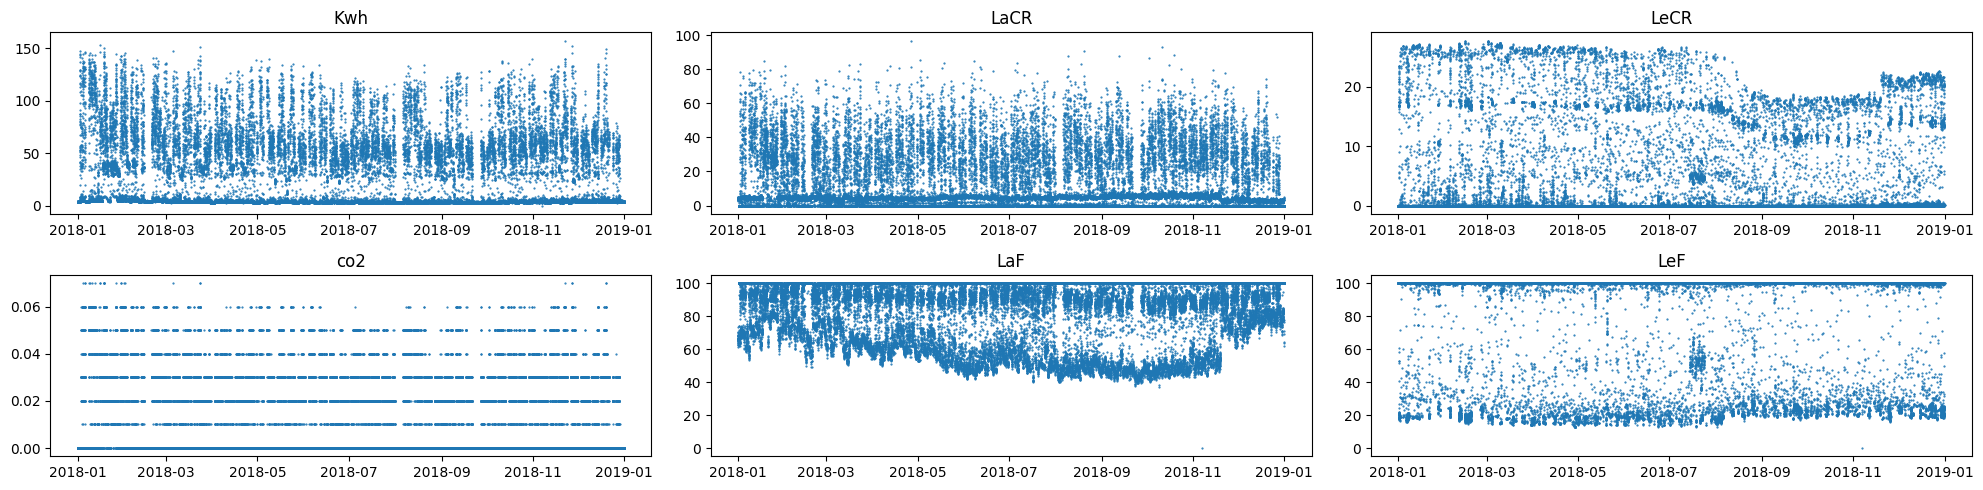


독립변수들의 시계열 산점도를 그렸다. 시계열적 특성은 보이지 않으나. 18년 8월, 9월말에 비어있는 구간이 있는 것처럼 보인다.
LeCR 18년 9~12월 기간은 타 기간에 비해 상대적으로 낮은 수치를 보인다.



In [61]:
import matplotlib.pyplot as plt
import seaborn as sns


fig,axes = plt.subplots(2,3,figsize=(20,5))
for i,ax in enumerate(axes.flat):
    target_df = df[['date',df.columns[1:][i]]]
    ax.scatter(x = target_df['date'],y= target_df[df.columns[1:][i]],s=0.3)
    ax.set_title(df.columns[1:][i])
    
fig.tight_layout()
plt.show()

print('''
독립변수들의 시계열 산점도를 그렸다. 시계열적 특성은 보이지 않으나. 18년 8월, 9월말에 비어있는 구간이 있는 것처럼 보인다.
LeCR 18년 9~12월 기간은 타 기간에 비해 상대적으로 낮은 수치를 보인다.
''')

## 1-5 Kwh8를 종속 변수로 하여(Kwh제거) 분류 모델을 학습하고 평가하라. 서포트벡터머신과 랜덤포레스트를 사용하라. confusionmatrix를 해석하라

파생변수 ind11칼럼의 값이 1인 데이터만 훈련에 사용할 것, ind22칼럼의 값이 1인 데이터만 테스트에 사용할 것    
모든 모델링은 그리드서치를 통해서 최적 파라미터를 산출할 것 (각 모델의 파라미터는 3개 이하로)

In [67]:
from sklearn.pipeline import Pipeline
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix , accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train = df[df.ind11 ==1]
test = df[df.ind22 ==1]


train_x = train.drop(columns = ['Kwh','Kwh8','date'])
train_y = train['Kwh8']

test_x = test.drop(columns = ['Kwh','Kwh8','date'])
test_y = test['Kwh8']


def rf_modeling(train_x,train_y):
    rf = RandomForestClassifier(random_state=123)
    param_grid = {
        'n_estimators':[100,10],
        'min_samples_split':[2,5],
        'min_samples_leaf':[1,3],
    }
    
    grid_search = GridSearchCV(rf,param_grid , refit=True,cv =3)
    grid_search.fit(train_x,train_y)
    return grid_search
    
def svc_modeling(train_x,train_y):
    
    
    svc = SVC()
    param_grid = {
        'svc__C':[1,10],
        'svc__kernel':['linear','rbf'],
        'svc__tol':[0.001,0.01],
    }
    
    pipeline = Pipeline([('scaler', StandardScaler()), ('svc', SVC())])
    
    grid_search = GridSearchCV(pipeline,param_grid , refit=True,cv =3)
    grid_search.fit(train_x,train_y)
    return grid_search    
    
    
rf = rf_modeling(train_x,train_y)
svc = svc_modeling(train_x,train_y)

In [81]:
rf_pred = rf.predict(test_x)
svc_pred = svc.predict(test_x)

rf_confusion = pd.DataFrame(confusion_matrix(test_y,rf_pred),index = ['0_true','1_true'],columns =['0_guess','1_guess'])
rf_result_accuracy = accuracy_score(test_y,rf_pred)
rf_confusion.columns.name =f'RandomForest accuracy : {round(rf_result_accuracy,3)}'

svc_confusion = pd.DataFrame(confusion_matrix(test_y,svc_pred),index = ['0_true','1_true'],columns =['0_guess','1_guess'])
svc_result_accuracy = accuracy_score(test_y,svc_pred)
svc_confusion.columns.name =f'SVC accuracy : {round(svc_result_accuracy,3)}'

display(rf_confusion)
display(svc_confusion)

print('''
    랜덤포레스트의 경우 모델정확도는 0.95로 0.939값을 가지는 서포트 벡터머신보다 높은 정확도를 보이며, confusion maxtrix의 결과는 위와 같다.
''')

RandomForest accuracy : 0.95,0_guess,1_guess
0_true,707,22
1_true,57,797


SVC accuracy : 0.939,0_guess,1_guess
0_true,702,27
1_true,69,785



    랜덤포레스트의 경우 모델정확도는 0.95로 0.939값을 가지는 서포트 벡터머신보다 높은 정확도를 보이며, confusion maxtrix의 결과는 위와 같다.



## 1-6 Kwh를 종속 변수로 하여(Kwh8 제거) 회귀 모델을 학습하고 평가하라. 서포트벡터머신과 랜덤포레스트를 사용하라

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix , accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

train = df[df.ind11 ==1]
test = df[df.ind22 ==1]
train_x = train.drop(columns = ['Kwh','Kwh8','date'])
train_y = train['Kwh']
test_x = test.drop(columns = ['Kwh','Kwh8','date'])
test_y = test['Kwh']


def rf_modeling(train_x,train_y):
    rf = RandomForestRegressor(random_state=123)
    param_grid = {
        'n_estimators':[100,10],
        'min_samples_split':[2,5],
        'min_samples_leaf':[1,3],
    }
    
    grid_search = GridSearchCV(rf,param_grid , refit=True,cv =3)
    grid_search.fit(train_x,train_y)
    return grid_search
    
def svr_modeling(train_x,train_y):
    svr = SVR()
    param_grid = {
        'svr__C':[1,10],
        'svr__kernel':['linear','rbf'],
        'svr__tol':[0.001,0.01],
    }
    
    pipeline = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])
    
    grid_search = GridSearchCV(pipeline,param_grid , refit=True,cv =3)
    grid_search.fit(train_x,train_y)
    return grid_search    
    
    
rf = rf_modeling(train_x,train_y)
svr = svr_modeling(train_x,train_y)
rf_pred = rf.predict(test_x)
svr_pred = svr.predict(test_x)


from sklearn.metrics import mean_squared_error
rf_mse = mean_squared_error(test_y, rf_pred)
svr_mse = mean_squared_error(test_y, svr_pred)

print(f'''
랜덤포레스트의 mse값은 {round(rf_mse)}이고 서포트 백터머신의 mse값은 {round(svr_mse)}이므로 랜덤포레스트의 성능이 더 좋은 것을 확인할 수 있다
''')


랜덤포레스트의 mse값은 8이고 서포트 백터머신의 mse값은 24이므로 랜덤포레스트의 성능이 더 좋은 것을 확인할 수 있다



## 1-7 아래 두 조건으로 각각 데이터를 추출하여 회귀 모델링을 하고 1-6과 성능을 비교하라
- Kwh8 값이 1인 데이터만 추출 후 Kwh8 컬럼 제거
- Kwh8 값이 0인 데이터만 추출 후 Kwh8 컬럼 제거

In [107]:
df_filter_one = df[df['Kwh8'] ==1]
df_filter_zero = df[df['Kwh8'] ==0]

def total_model(df):
    train = df[df.ind11 ==1]
    test = df[df.ind22 ==1]
    train_x = train.drop(columns = ['Kwh','Kwh8','date'])
    train_y = train['Kwh']
    test_x = test.drop(columns = ['Kwh','Kwh8','date'])
    test_y = test['Kwh']


    def rf_modeling(train_x,train_y):
        rf = RandomForestRegressor(random_state=123)
        param_grid = {
            'n_estimators':[100,10],
            'min_samples_split':[2,5],
            'min_samples_leaf':[1,3],
        }

        grid_search = GridSearchCV(rf,param_grid , refit=True,cv =3)
        grid_search.fit(train_x,train_y)
        return grid_search

    def svr_modeling(train_x,train_y):
        svr = SVR()
        param_grid = {
            'svr__C':[1,10],
            'svr__kernel':['linear','rbf'],
            'svr__tol':[0.001,0.01],
        }

        pipeline = Pipeline([('scaler', StandardScaler()), ('svr', SVR())])

        grid_search = GridSearchCV(pipeline,param_grid , refit=True,cv =3)
        grid_search.fit(train_x,train_y)
        return grid_search    


    rf = rf_modeling(train_x,train_y)
    svr = svr_modeling(train_x,train_y)
    rf_pred = rf.predict(test_x)
    svr_pred = svr.predict(test_x)

    from sklearn.metrics import mean_squared_error
    rf_mse = mean_squared_error(test_y, rf_pred)
    svr_mse= mean_squared_error(test_y, svr_pred)
    
    return rf_mse , svr_mse



rf_mse_one,svr_mse_one = total_model(df_filter_one)
rf_mse_zero,svr_mse_zero = total_model(df_filter_zero)
result_df = pd.DataFrame()
result_df.index = ['랜덤포레스트','서포트벡터머신']
result_df['Kwh8 ==1'] = [round(rf_mse_one,2),round(svr_mse_one,2)]
result_df['Kwh8 ==0'] = [round(rf_mse_zero,2),round(svr_mse_zero,2)]
result_df.columns.name ='mse'
display(result_df)
print('kwh8 ==0 인 경우가 1인 경우보다 더 좋은 모델 결과를 보였다. 두 경우 모두 랜덤포레스트가 서포트 벡터머신보다 좋은 결과를 보였다.')

mse,Kwh8 ==1,Kwh8 ==0
랜덤포레스트,14.87,0.02
서포트벡터머신,39.55,0.04


kwh8 ==0 인 경우가 1인 경우보다 더 좋은 모델 결과를 보였다. 두 경우 모두 랜덤포레스트가 서포트 벡터머신보다 좋은 결과를 보였다.


## 데이터 설명
- 데이터 출처 : https://www.data.go.kr/data/15126430/fileData.do 후처리 + 자체제작
- 데이터 링크 : 
    - ./data/32/adp32_p2.csv
    - ./data/32/adp32_p2_sub.csv
- 데이터 설명 : 
    - 두가지 데이터이다. 
    - adp32_p2.csv : J시의 4개의 발전기의 시간당 발전용량에 대한 정보이다.
    - adp32_p2_sub.csv : J시의 시간별 계절성 정보 데이터이다.

In [342]:
dt2_1 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_p2.csv')
dt2_2 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_p2_sub.csv')

In [343]:
# 4개 발전기의 시간당 발전용량:: 일단 null 값은 없음
print(dt2_1.info())
dt2_1.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   발전기명    4380 non-null   object 
 1   일자      4380 non-null   object 
 2   설비용량    4380 non-null   float64
 3   0시      4380 non-null   float64
 4   1시      4380 non-null   float64
 5   2시      4380 non-null   float64
 6   3시      4380 non-null   float64
 7   4시      4380 non-null   float64
 8   5시      4380 non-null   float64
 9   6시      4380 non-null   float64
 10  7시      4380 non-null   float64
 11  8시      4380 non-null   float64
 12  9시      4380 non-null   float64
 13  10시     4380 non-null   float64
 14  11시     4380 non-null   float64
 15  12시     4380 non-null   float64
 16  13시     4380 non-null   float64
 17  14시     4380 non-null   float64
 18  15시     4380 non-null   float64
 19  16시     4380 non-null   float64
 20  17시     4380 non-null   float64
 21  18시     4380 non-null   float64
 22  

,발전기명,일자,설비용량,0시,1시,2시,3시,4시,5시,6시,...,14시,15시,16시,17시,18시,19시,20시,21시,22시,23시
0,a,2020-01-01,263.225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,93.280,53.840,21.630,5.690,4.610,4.270,1.330,0.530,0.0,0.0
1,b,2020-01-01,245.725,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,88.250,51.059,22.283,5.244,4.183,3.848,1.290,0.564,0.0,0.0
2,c,2020-01-01,254.425,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,90.641,50.344,22.072,5.652,4.495,4.089,1.240,0.526,0.0,0.0
3,d,2020-01-01,250.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,86.995,51.953,21.831,6.149,4.666,4.141,1.228,0.491,0.0,0.0


In [344]:
# 4개 발전기의 시간별 계절성 정보: 일부 null 값 존재
print(dt2_2.info())
print(dt2_2.isna().sum())
dt2_2.head(4)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   일시         26280 non-null  object 
 1   기온         26275 non-null  float64
 2   강수량(mm)    26278 non-null  float64
 3   습도         26280 non-null  float64
 4   적설(cm)     26280 non-null  float64
 5   전운량(10분위)  26280 non-null  int64  
 6   일조(hr)     26279 non-null  float64
 7   일사량        26280 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 1.6+ MB
None
일시           0
기온           5
강수량(mm)      2
습도           0
적설(cm)       0
전운량(10분위)    0
일조(hr)       1
일사량          0
dtype: int64


,일시,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량
0,2020-01-01 00:00,2.4,NaN,63.0,0.0,9,0.0,0.0
1,2020-01-01 01:00,2.6,0.0,63.0,0.0,9,0.0,0.0
2,2020-01-01 02:00,2.7,0.0,68.0,0.0,9,0.0,0.0
3,2020-01-01 03:00,3.2,0.0,69.0,0.0,9,0.0,0.0


## 2-1 아래 조건들을 참고하여 전처리를 시행하라
- 계절성 정보 데이터 중 강수량과 일조량의 결측치를 0으로 채워라
- 계절성 정보 데이터 중 기온은 직전시간과 직후시간의 기온의 평균값으로 결측치를 대치하라
- 계절성 정보데이터와 발전용량 데이터를 머지하라.
    - 계절성 정보데이터의 일자,시각을 기준으로 한다.
    - 계절성 정보데이터에 발전기명, 설비용량, 발전량 컬럼을 추가한다.

In [345]:
# 0값으로 대치
dt2_2['강수량(mm)'] = dt2_2['강수량(mm)'].fillna(0)
dt2_2['일조(hr)'] = dt2_2['일조(hr)'].fillna(0)
# 직전/직후 평균
dt2_2['기온'] = dt2_2['기온'].fillna((dt2_2['기온'].shift(1)+dt2_2['기온'].shift(-1))/2)
dt2_2['기온'] = dt2_2['기온'].fillna(dt2_2['기온'].shift(-1))
dt2_2['기온'] = dt2_2['기온'].fillna((dt2_2['기온'].shift(1)+dt2_2['기온'].shift(-1))/2)                                 
dt2_2.isna().sum()

일시           0
기온           0
강수량(mm)      0
습도           0
적설(cm)       0
전운량(10분위)    0
일조(hr)       0
일사량          0
dtype: int64

In [350]:
# 데이터프레임 머지
tmp = dt2_1.melt(id_vars=['발전기명', '일자', '설비용량'], var_name='시간', value_name='발전량')
tmp['시간'] = tmp['시간'].str[:-1].astype('int64')
tmp = tmp.sort_values(by=['일자','시간'])

dt2_2['일자'] = dt2_2['일시'].str[:10]
dt2_2['시간'] = dt2_2['일시'].str[-5:-3].astype('int64')
dt2_2.drop(columns='일시', inplace=True)

mg_dt = pd.merge(dt2_2, tmp[['일자', '시간', '발전기명', '설비용량', '발전량']], how='left', on=['일자', '시간'])
mg_dt = mg_dt[['일자', '시간', '발전기명', '설비용량', '기온', '강수량(mm)', '습도', '적설(cm)', '전운량(10분위)', '일조(hr)', '일사량',  '발전량']]
mg_dt.head(16)

,일자,시간,발전기명,설비용량,기온,강수량(mm),습도,적설(cm),전운량(10분위),일조(hr),일사량,발전량
0,2020-01-01,0,a,263.225,2.4,0.0,63.0,0.0,9,0.0,0.0,0.0
1,2020-01-01,0,b,245.725,2.4,0.0,63.0,0.0,9,0.0,0.0,0.0
2,2020-01-01,0,c,254.425,2.4,0.0,63.0,0.0,9,0.0,0.0,0.0
3,2020-01-01,0,d,250.125,2.4,0.0,63.0,0.0,9,0.0,0.0,0.0
4,2020-01-01,1,a,263.225,2.6,0.0,63.0,0.0,9,0.0,0.0,0.0
5,2020-01-01,1,b,245.725,2.6,0.0,63.0,0.0,9,0.0,0.0,0.0
6,2020-01-01,1,c,254.425,2.6,0.0,63.0,0.0,9,0.0,0.0,0.0
7,2020-01-01,1,d,250.125,2.6,0.0,63.0,0.0,9,0.0,0.0,0.0
8,2020-01-01,2,a,263.225,2.7,0.0,68.0,0.0,9,0.0,0.0,0.0
9,2020-01-01,2,b,245.725,2.7,0.0,68.0,0.0,9,0.0,0.0,0.0


## 2-2. 전처리 데이터를 기준으로 아래 조건으로 train,test 데이터를 나눈다.   데이터 분리 후 train 데이터의 기초 통계량을 확인하라
- a발전기의 12시~18시의 데이터만 모델링에 사용한다. 
- 2020년도, 2021년도는 train, 2022년도는 test 데이터로 사용한다

In [376]:
m_dt = mg_dt[(mg_dt['시간'].between(12, 18)) & (mg_dt['발전기명'] == 'a')]

train = m_dt[m_dt['일자'].str[:4].isin(['2020', '2021'])]
test = m_dt[m_dt['일자'].str[:4].isin(['2022'])]

train.shape, test.shape

((5110, 12), (2555, 12))

<train set>


,count,mean,std,min,25%,50%,75%,max
시간,5110.0,15.000000,2.000196,12.000,13.000,15.0000,17.0000,18.000
설비용량,5110.0,290.191007,14.075334,263.225,282.355,289.6985,299.6970,318.119
기온,5110.0,18.723346,7.671239,-2.000,12.800,19.1000,24.7000,35.600
강수량(mm),5110.0,0.206419,1.762871,0.000,0.000,0.0000,0.0000,74.600
습도,5110.0,65.166928,15.126223,14.000,54.000,65.0000,76.0000,100.000
적설(cm),5110.0,0.027926,0.392822,0.000,0.000,0.0000,0.0000,8.800
전운량(10분위),5110.0,5.985519,3.686239,0.000,2.000,7.0000,9.0000,10.000
일조(hr),5110.0,0.497162,0.440233,0.000,0.000,0.5000,1.0000,1.000
일사량,5110.0,1.413086,1.054632,0.000,0.470,1.2100,2.2875,3.690
발전량,5110.0,78.277661,67.321926,0.030,17.890,58.8600,131.5250,247.560


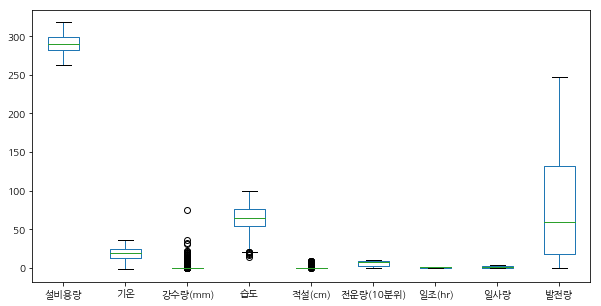

In [382]:
dt_list = [('<train set>', train)]
col_list = train.select_dtypes('number').columns[1:]

for name, dt in dt_list:
    print(name)
    display(dt.describe().T)
#kde를 그릴 수도 있지만 boxplot을 그려 이상치를 한번에 본다.
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    dt[col_list].plot(kind='box', ax=ax)
plt.show()

box plot 상 강수량, 습도, 적설량에서 이상치가 관찰된다. 

## 2-3. train 데이터 세트의 발전량과 나머지 변수간의 상관관계를 확인하라


In [386]:
corr = train[col_list].corr()['발전량'][:-1].sort_values()
corr

전운량(10분위)   -0.484490
습도          -0.383281
강수량(mm)     -0.099701
적설(cm)      -0.067622
설비용량        -0.020767
기온           0.117676
일조(hr)       0.598131
일사량          0.857487
Name: 발전량, dtype: float64

전운량은 발전량과의 상관계수가 -0.484로, 모든 변수 중 가장 큰 음의 상관관계를 보였다.  
이는 전운량이 증가할수록 발전량은 감소하는 경향이 있다는 것을 의미한다.

반면, 일사량은 발전량과의 상관계수가 0.857로, 가장 큰 양의 상관관계를 나타내며,  
일사량이 많을수록 발전량이 증가하는 경향이 강하게 나타났다.

## 2-4. 발전량을 종속변수로 하여 2개의 회귀모델링을 진행하고 모델을 평가하라

종속변수의 값이 연속형 변수이며, 이를 예측하는 모델을 구현해야 하기 때문에 회귀모형을 구축한다.  
- 트리기반의 앙상블 모델로 비교적 성능이 좋으며, 데이터의 비선형관계를 잘 설명하고 스케일링이 불필요한 랜덤포레스트를 선택 
- 선형회귀모형을 비교를 위해 사용(수 간 선형 관계를 가정하는 모델로, 해석이 용이하고 기초 회귀분석의 기준 모델로 자주 활용)

성능지표는 rmse로 테스트셋의 score로 평가한다. 

In [391]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(random_state=0)
lr = LinearRegression()

#데이터셋 가공
x_list = ['시간', '발전기명', '설비용량', '기온', '강수량(mm)', '습도', '적설(cm)', '전운량(10분위)', '일조(hr)', '일사량']
train_X = train[x_list]
test_X = test[x_list]
train_Y = train['발전량']
test_Y = test['발전량']

#시간, 발전기명은 get_dummies
train_X = pd.get_dummies(train_X, columns=['시간', '발전기명'], drop_first=True)
test_X = pd.get_dummies(test_X, columns=['시간', '발전기명'], drop_first=True)


rf.fit(train_X, train_Y)
lr.fit(train_X, train_Y)

#테스트셋으로 평가
pred1 = rf.predict(test_X)
pred2 = lr.predict(test_X)
rmse1 = np.sqrt(mean_squared_error(test_Y, pred1))
rmse2 = np.sqrt(mean_squared_error(test_Y, pred2))

print(f"랜덤포레스트 RMSE: {rmse1}")
print(f"선형회귀 RMSE: {rmse2}")

랜덤포레스트 RMSE: 30.15393003787261
선형회귀 RMSE: 30.597849749830264


랜덤포레스트의 RMSE가 비교 모델인 선형회귀의 성능보다 더 좋은 것을 확인할 수 있다.
- 랜덤포레스트 RMSE: 30.15393003787261
- 선형회귀 RMSE: 30.597849749830264

# 통계 (40점)

## 데이터 설명
- 데이터 출처 : https://www.kaggle.com/code/prasadperera/the-boston-housing-dataset 후처리
- 데이터 링크 : ./data/32/adp32_s1.csv
- 데이터 설명 : 보스턴 집값 관련 데이터
    - MEDV (집값): 종속변수

In [189]:
dt3 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_s1.csv')
print(dt3.info())
display(dt3.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   AGE      506 non-null    float64
 6   DIS      506 non-null    float64
 7   RAD      506 non-null    float64
 8   TAX      506 non-null    float64
 9   PTRATIO  506 non-null    float64
 10  B        506 non-null    float64
 11  LSTAT1   506 non-null    float64
 12  LSTAT2   506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB
None


,CRIM,ZN,INDUS,CHAS,NOX,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT1,LSTAT2,MEDV
0,0.00632,18.0,2.31,0.0,0.538,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,5.052,24.0
1,0.02731,0.0,7.07,0.0,0.469,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,9.444,21.6
2,0.02729,0.0,7.07,0.0,0.469,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,3.897,34.7


## 3-1 기본 회귀가정을 검토하라

선형회귀는 결측치와 이상치에 민감하다. 또한 잔차의 기본가정을 만족해야 한다.

<선형회귀의 가정>

- 정규성: 잔차가 정규분포의 형태를 띔
- 등분산성: 독립변수와 무관하게 잔차의 분산이 일정함
- 선형성: 종속변수는 설명변수와 회귀계수의 선형결합으로 표현 가능
- 독립성: 잔차들은 서로 독립, 독립변수들은 서로 선형적으로 독립
    
각 변수별 결측치는 없으나, 눈에 띄는 이상치가 있는지 분포를 확인한다.

In [190]:
dt3.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677082,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000
PTRATIO,506.0,18.455534,2.164946,12.60000,17.400000,19.05000,20.200000,22.0000


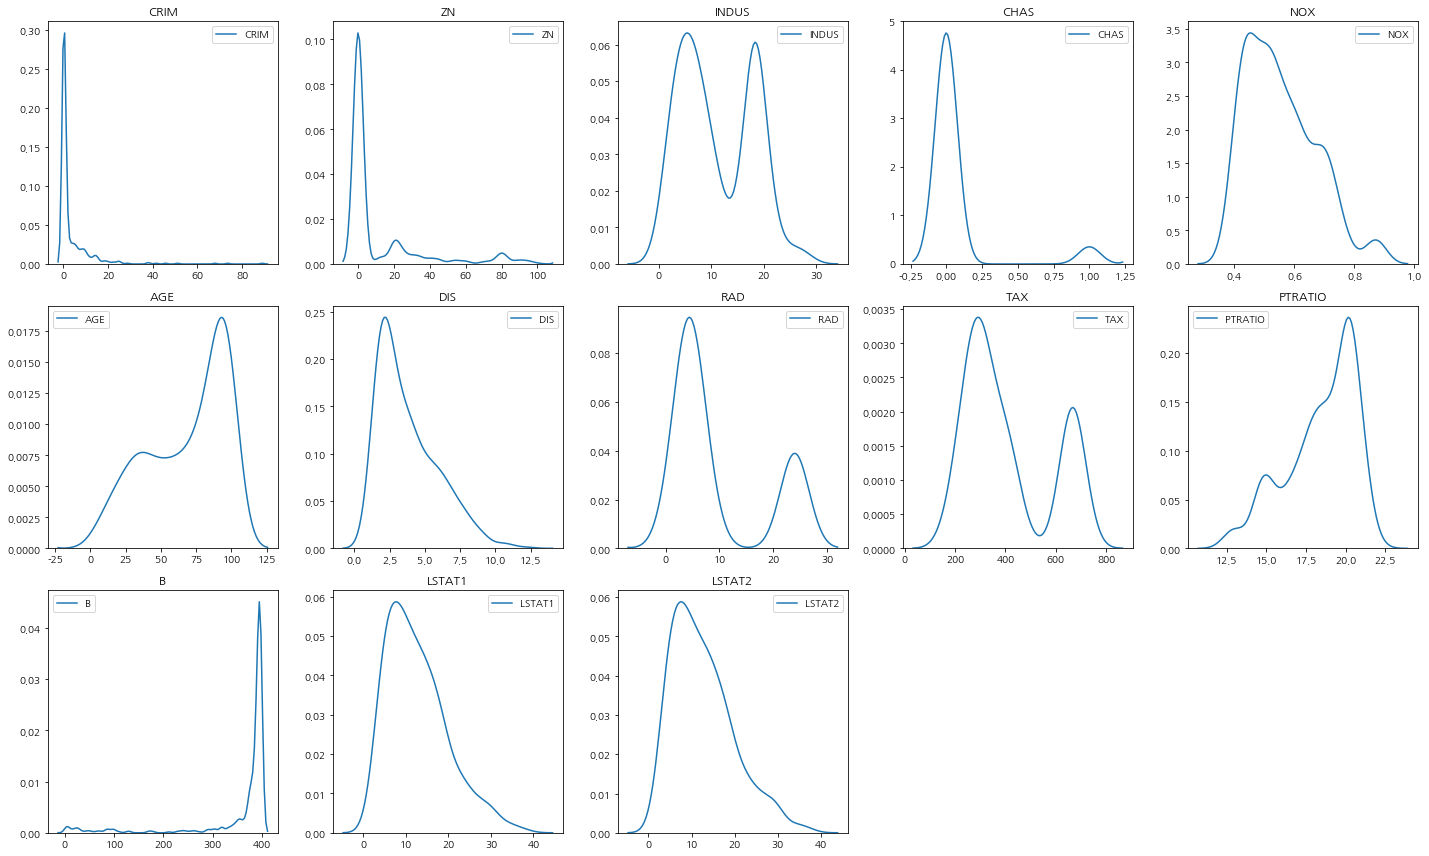

In [191]:
col_list = dt3.columns[:-1]

fig, ax = plt.subplots(3, 5, figsize=(20, 12))

for i, col in enumerate(col_list):
    x = i // 5
    y = i % 5
    sns.kdeplot(dt3[col], ax=ax[x, y])
    ax[x, y].set_title(col)
plt.tight_layout()
ax[2, 3].remove()
ax[2, 4].remove()
plt.show()

각 설명변수와 종속변수인 MEDW와의 산점도를 그려보았다. 이를 통해 설명변수-종속변수 간 상관관계,  
이상치를 대략적으로 확인가능하다.  

<설명-종속변수 간 상관관계>
- LSTAT1: 음의 상관관계
- LSTAT2: 음의 상관관계

<이상치>
- CRIM: 40 이상의 값이 이상치로 보임

In [192]:
# 다음으로 잔차의 회귀가정을 확인하기 위해 선형회귀분석 실시
# CHAS는 이진변수: 카테고리

import statsmodels.formula.api as smf

model = smf.ols(formula='MEDV~CRIM+ZN+INDUS+C(CHAS)+NOX+AGE+DIS+RAD+TAX+PTRATIO+B+LSTAT1+LSTAT2', data=dt3).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.689
Method:                 Least Squares   F-statistic:                     87.03
Date:                Wed, 23 Jul 2025   Prob (F-statistic):          2.09e-118
Time:                        13:12:18   Log-Likelihood:                -1538.2
No. Observations:                 506   AIC:                             3104.
Df Residuals:                     492   BIC:                             3164.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         69.4437      3.888     17.

#### 1. 독립성 검정: Durbin-Watson

| DW 값 범위        | 해석                                              |
| -------------- | ----------------------------------------------- |
| **0 \~ 1.5**   | **양(+)의 자기상관 존재 가능성** 높음 → 잔차들이 서로 비슷한 방향으로 이동함 |
| **1.5 \~ 2.5** | **자기상관 없음 (or 매우 약함)** → 회귀모형 적절                |
| **2.5 \~ 4.0** | **음(-)의 자기상관 존재 가능성** → 잔차가 번갈아가며 방향이 바뀜        |


위 summary에서도 확인할 수 있으며, 1.246으로 독립을 만족하지 못한다.(양의 자기상관 존재 가능성 높음)

In [193]:
from statsmodels.stats.stattools import durbin_watson

durbin_watson(model.resid)

1.2456130251692965

#### 2. 등분산성 검정: breusch-pagan

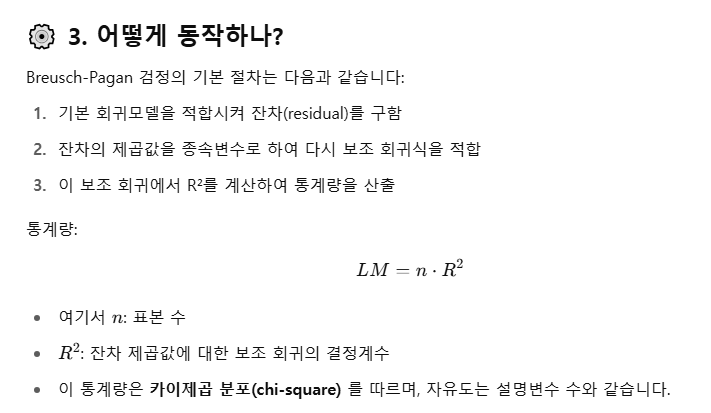

<가정: 유의수준 5% 하>
- H0: 모델의 잔차가 등분산이다. 
- H1: 모델의 잔차가 등분산이 아니다.

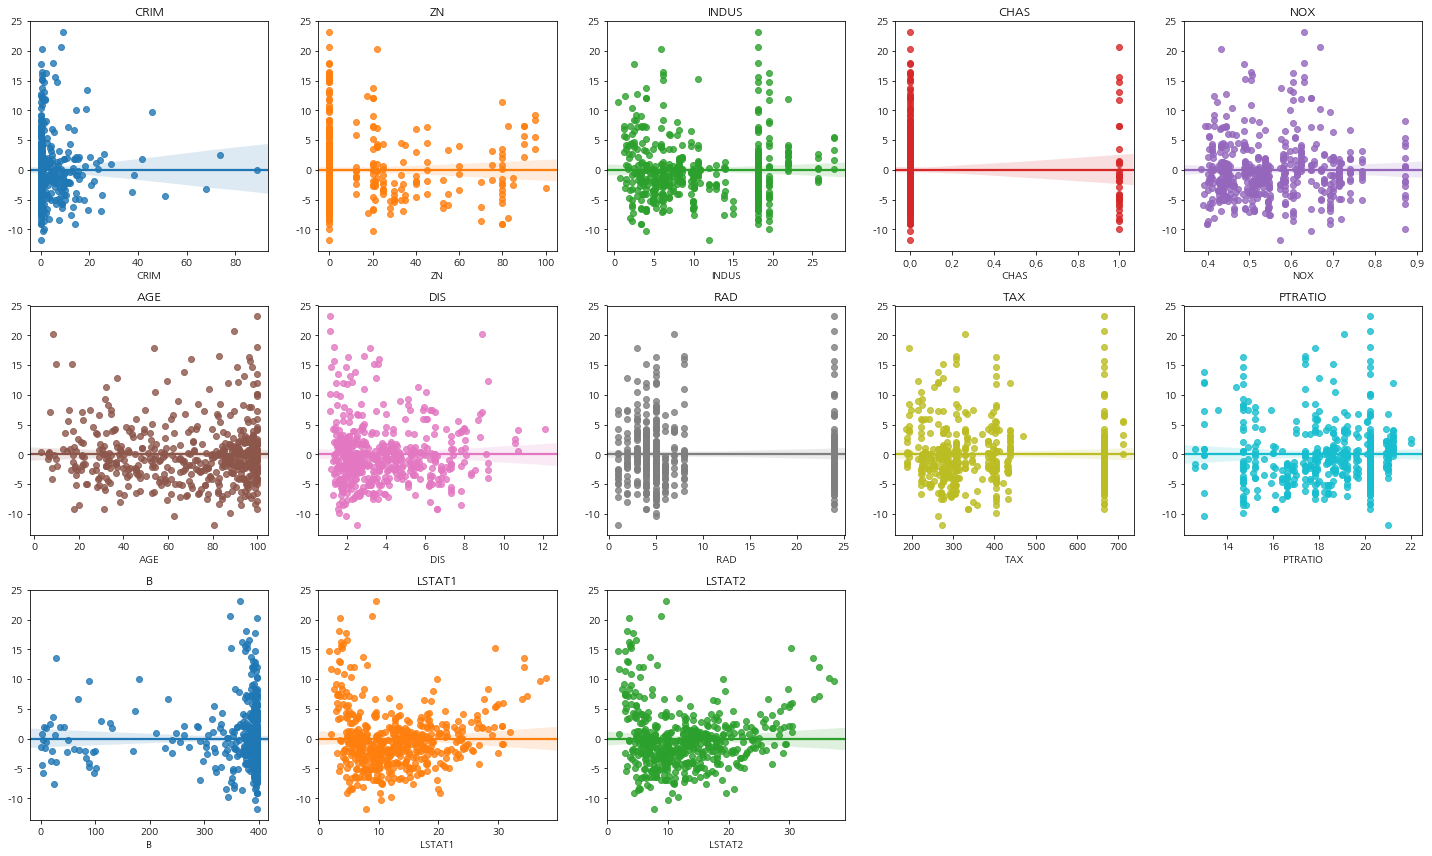

p-value(0.000)로 귀무가설을  기각(등분산 아님)


In [194]:
# 각 설명변수별 잔차 그래프
fig, ax = plt.subplots(3, 5, figsize=(20, 12))

for i, col in enumerate(col_list):
    x = i // 5
    y = i % 5
    sns.regplot(x=dt3[col], y=model.resid, ax=ax[x, y])
    ax[x, y].set_title(col)
plt.tight_layout()
ax[2, 3].remove()
ax[2, 4].remove()
plt.show()

# breuch-pagan 검정
from statsmodels.stats.api import het_breuschpagan

static, p,f_static, f_p = het_breuschpagan(model.resid, model.model.exog) #잔차, 입력 설명변수값
print(f"p-value({p:.3f})로 귀무가설을 ", "기각(등분산 아님)" if p < 0.05 else "기각x(등분산 만족)")

#### 3. 정규성: jarque_bera

<가정: 유의수준 5% 하>
- H0: 모델의 잔차가 정규분포를 따른다.
- H1: 모델의 잔차가 정규분포를 따르지 않는다.

통계량: 298.364
왜도: 1.281
첨도: 5.754
p-value(0.000)로 귀무가설을  기각(정규분포 아님)


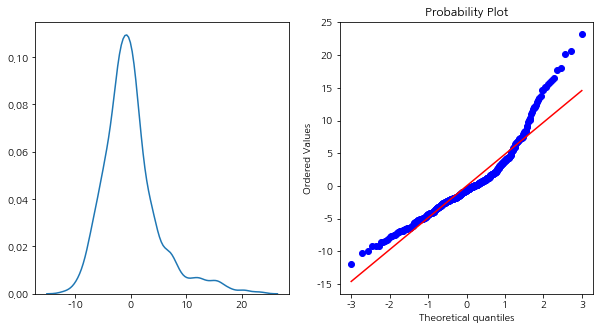

In [195]:
from statsmodels.stats.stattools import jarque_bera
from scipy.stats import probplot

stats, p, skew, kurt = jarque_bera(model.resid)

out_list = [('통계량', stats), ('왜도', skew), ('첨도', kurt)] #정규분포 왜도: 0, 첨도: 3
for n, v in out_list:
    print(f"{n}: {v:.3f}")
print(f"p-value({p:.3f})로 귀무가설을 ", "기각(정규분포 아님)" if p < 0.05 else "기각x(정규분포 따름)")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.kdeplot(model.resid, ax=ax[0])
probplot(model.resid, plot=ax[1])
plt.show()

#### 4.  선형성: 잔차-예측값 산점도

잔차가 랜덤하게 퍼져야 선형성 만족, 패턴이 있다면 비선형

| 항목        | 이상적 모습                  | 현재 결과                           |
| --------- | ----------------------- | ------------------------------- |
| **점의 분포** | 수평으로 무작위로 흩어져 있어야 함     | **잔차가 특정 영역에서 뭉쳐 있는 듯한 경향**이 있음 |
| **패턴 여부** | 곡선, 선, 팬 모양 등 없이 랜덤해야 함 | **약한 곡선 형태** 및 **비대칭적인 확산**이 보임 |
| **잔차 범위** | 고르게 퍼져 있어야 함            | 일부 구간(예: 0 부근)에 **잔차가 집중**됨     |


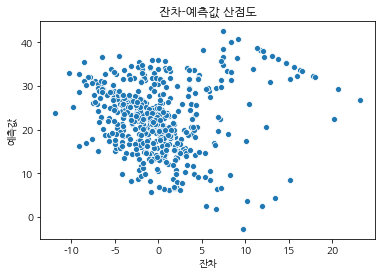

In [196]:
sns.scatterplot(x=model.resid, y=model.fittedvalues)
plt.title('잔차-예측값 산점도')
plt.xlabel('잔차')
plt.ylabel('예측값')
plt.show()

위 결과를 통해 선형회귀의 기본가정인 잔차의 선형성, 정규성, 등분산성, 독립성을 모두 만족하지 않는다는 사실을 확인할 수 있다.

## 3-2. 변수간 관계 검토하고 문제점 해결방안 2가지를 제시하라.

1. 변수 로그변환
  비선형 관계를 해결하기 위해 일부 변수에 로그변환을 수행한다. 이 문제에서는 왜도가 0 초과하며 오른쪽 긴꼬리 연속형 변수 기준으로 변환한다.
  - CRIM, ZN, DIS, LSTAT1, LSTAT2
  
| 특성                            | 설명                      |
| ----------------------------- | ----------------------- |
| **양의 값만 있음**                  | 로그 함수의 정의역에 맞음          |
| **오른쪽으로 긴 꼬리(positive skew)** | 로그 변환이 분포를 정규에 가깝게 만들어줌 |
| **종속변수와의 관계가 비선형 (곡선형)**      | 로그 변환 시 선형관계가 될 수 있음    |

2. 다중공선성 제거: 변수선택 또는 차원축소  
  다중공선성 발생 시 선형회귀의 계수 추정이 불안해지므로 **VIF 값을 기준으로 값이 큰 변수를 제거**하거나,  
  **PCA(주성분 분석)** 를 통해 변수 간 중복을 제거한 축으로 변환한다. 


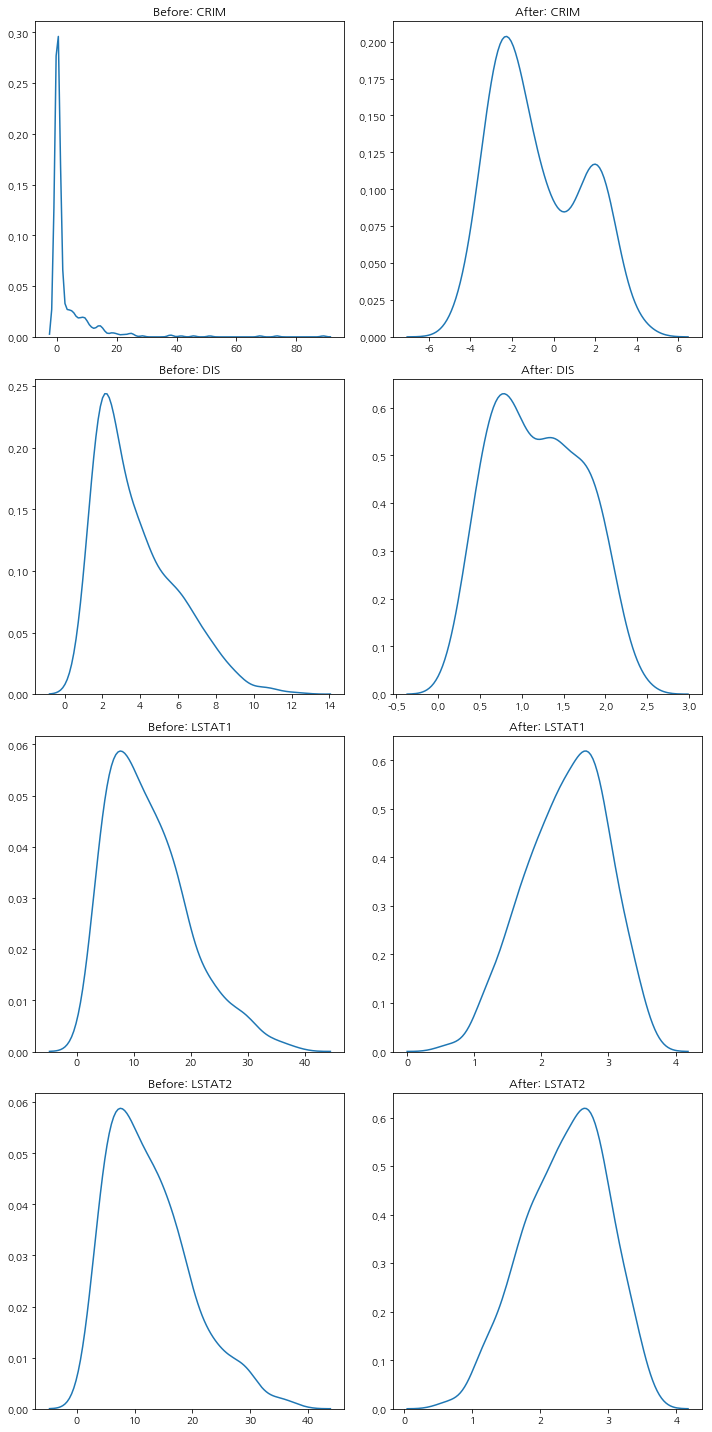

In [197]:
#1. 로그변환: 0 이하의 값이 없을 것, 왜도가 +일 것
col_list2 = ['CRIM', 'DIS', 'LSTAT1', 'LSTAT2']

dt3_r = dt3.copy()

fig, ax = plt.subplots(4, 2, figsize=(10, 20))

for i, col in enumerate(col_list2):
    dt3_r[col] = np.log(dt3_r[col])
    sns.kdeplot(dt3[col], ax=ax[i, 0], legend=False)
    sns.kdeplot(dt3_r[col], ax=ax[i, 1], legend=False)
    ax[i, 0].set_title(f'Before: {col}')  # 왼쪽 열 제목
    ax[i, 1].set_title(f'After: {col}')   # 오른쪽 열 제목
plt.tight_layout()
plt.show()

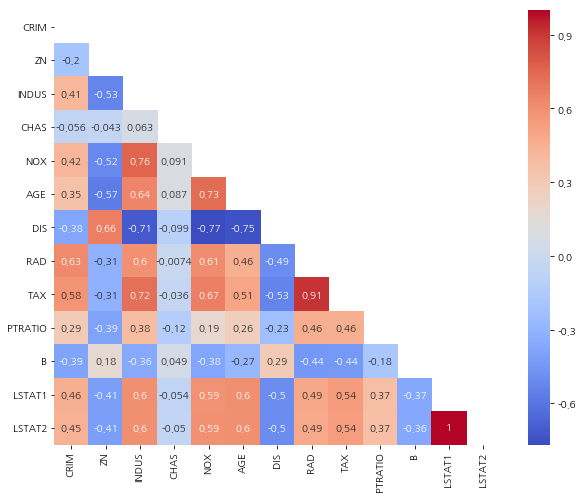

In [198]:
#2. 다중공선성 확인
plt.figure(figsize=(10, 8))
corr = dt3[col_list].corr()
mask = np.triu(np.ones_like(corr, dtype='bool'))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

In [199]:
tmp = corr.reset_index().melt(id_vars='index')
tmp['value1'] = np.abs(tmp['value'])
tmp = tmp.sort_values(by='value1', ascending=False)
tmp = tmp[(tmp['index'] != tmp['variable']) & (tmp['value1'] >= 0.7)] #임의로 0.7이상인 값을 찾음
tmp

,index,variable,value,value1
155,LSTAT2,LSTAT1,0.998273,0.998273
167,LSTAT1,LSTAT2,0.998273,0.998273
99,TAX,RAD,0.910228,0.910228
111,RAD,TAX,0.910228,0.910228
58,DIS,NOX,-0.769230,0.769230
82,NOX,DIS,-0.769230,0.769230
54,INDUS,NOX,0.763651,0.763651
30,NOX,INDUS,0.763651,0.763651
83,AGE,DIS,-0.747881,0.747881
71,DIS,AGE,-0.747881,0.747881


선형(피어슨) 상관관계에서 절대값 0.7 이상의 값을 상관관계가 강하다고 보았을 때 대다수의 변수 쌍에서 강한 상관관계 발견  
다중공선성이 강한 데이터셋이라고 볼 수 있다.
다음으로 vif 값을 확인한다. 

In [200]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = pd.DataFrame()

vif_df['feature'] = model.model.exog_names
vif_df['vif'] = [variance_inflation_factor(model.model.exog, i) for i in range(model.model.exog.shape[1])]

vif_df[1:]

,feature,vif
1,C(CHAS)[T.1.0],1.074816
2,CRIM,1.830536
3,ZN,2.244940
4,INDUS,3.958267
5,NOX,4.370295
6,AGE,2.968560
7,DIS,3.895383
8,RAD,7.297913
9,TAX,8.964227
10,PTRATIO,1.758946


VIF 값이 10 이상인 값을 다중공선성이 높은 feature로 보았을 때, LSTAT1, LSTAT2 가 식별되었다.   
해당 변수를 제거함으로써 다중공선성 문제를 줄일 수 있을 것이다.

In [201]:
# PCA: 차원축소 전 스케일링 실시
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#카테고리 변수 one-hot
dt3 = pd.get_dummies(dt3, columns=['CHAS'],drop_first=True)

Y = dt3['MEDV']
X = dt3.drop(columns=['MEDV'], axis=1)


train_X, test_X, train_Y, test_Y = train_test_split(X, Y, random_state=0)

sc = StandardScaler()

train_X  = sc.fit_transform(train_X)
test_X = sc.transform(test_X)

pca = PCA(n_components=0.9)


train_X_p = pca.fit_transform(train_X)
test_X_p = pca.transform(test_X)

누적설명분산률을 90%만 남기는 새로운 설명변수로 재생성하였다. 6개의 설명변수가 기존의 설명변수 기반으로 생성되었다.

## 3-3. 3-2에서 제안한 것을 반영하여 문제를 해결하고 적용 결과를 제시하라

In [202]:
def check_model(m):
    d = durbin_watson(m.resid) #독립성
    static, p1,f_static, f_p = het_breuschpagan(m.resid, m.model.exog) #잔차, 입력 설명변수값(등분산성)
    stats, p2, skew, kurt = jarque_bera(m.resid) #정규성
    print(f"durbin-watson 결과: {d:.3f}")
    print(f"등분산성 검정({p1:.3f}):", "만족" if p1 >= 0.05 else "불만족")
    print(f"정규성 검정({p2:.3f}):", "만족" if p2 >= 0.05 else "불만족")
    
    sns.scatterplot(x=m.resid, y=m.fittedvalues) #선형성 확인
    plt.title('잔차-예측값 산점도')
    plt.xlabel('잔차')
    plt.ylabel('예측값')
    plt.show()

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     127.4
Date:                Wed, 23 Jul 2025   Prob (F-statistic):          4.31e-148
Time:                        13:12:30   Log-Likelihood:                -1467.3
No. Observations:                 506   AIC:                             2963.
Df Residuals:                     492   BIC:                             3022.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         83.5252      3.749     22.

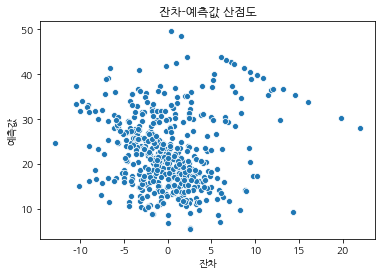

In [203]:
#1. 일부 비선형관계 변수 log화

model2 = smf.ols(formula='MEDV~CRIM+ZN+INDUS+C(CHAS)+NOX+AGE+DIS+RAD+TAX+PTRATIO+B+LSTAT1+LSTAT2', data=dt3_r).fit()

print(model2.summary())
check_model(model2)

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.118e+32
Date:                Wed, 23 Jul 2025   Prob (F-statistic):               0.00
Time:                        13:13:33   Log-Likelihood:                 16115.
No. Observations:                 506   AIC:                        -3.221e+04
Df Residuals:                     497   BIC:                        -3.217e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   5.135e-15   4.27e-16     12.017      0.0

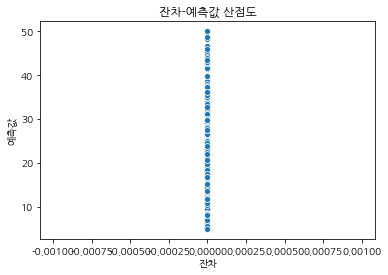

In [207]:
X = pd.DataFrame(np.concatenate([train_X_p, test_X_p], axis=0), columns=['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7'])
Y = pd.concat([train_Y, test_Y], axis=0)
dtt = pd.concat([X, Y], axis=1)
fm = '+'.join(dtt.columns)
model3 = smf.ols(formula=f'MEDV~{fm}', data=dtt).fit()

print(model3.summary())
check_model(model3)

두 방식 모두 적용했을 때 잔차의 기본가정을 만족하지 못하는 결과를 냈다.   
다만 R2(모델의 설명력)이 향상되었으며, 독립성 검정 값이 약간 향상된 것을 확인할 수 있다.

## 데이터 설명
- 데이터 출처 : https://www.rdocumentation.org/packages/datasets/versions/3.6.2/topics/mtcars 후처리
- 데이터 링크 : ./data/32/adp32_s2.csv
- 데이터 설명 : 차량정보데이터

## 4-1 cyl랑 gear 컬럼으로 교차테이블을 만들어라

In [208]:
dt4 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_s2.csv')
cr = pd.crosstab(dt4['cyl'], dt4['gear'])
cr

gear,3,4,5
cyl,,,
4,1,8,2
6,2,4,1
8,12,0,2


## 4-2 두 범주형 변수간 차이가 존재하는지 확인하려한다. 귀무가설과 대립가설을 작성하라

두 범주형 변수 간 차이가 존재하는지(독립인지 아닌지) 여부를 확인하기 위해서는 카이제곱 독립성 검정을 수행한다.

<유의수준 5% 하 가설 수립>
- H0: 두 범주형 변수 간 차이가 존재하지 않는다.(독립이다.)
- H1: 두 범주형 변수 간 차이가 존재한다.(독립이 아니다.)

<독립성 검정>

| 항목          | 내용                               |
| ----------- | -------------------------------- |
| **목적**      | 두 범주형 변수 간에 **독립적인지** 여부를 검정     |
| **예시**      | 성별과 제품 선호도 간에 연관성이 있는가?          |
| **귀무가설 H₀** | 두 변수는 **서로 독립**이다.               |
| **대립가설 H₁** | 두 변수는 **독립이 아니다 (연관 있음)**        |
| **데이터 형태**  | **교차표 (contingency table)**      |
| **사용 패키지**  | `scipy.stats.chi2_contingency()` |

<동질성 검정>

| 항목          | 내용                                          |
| ----------- | ------------------------------------------- |
| **목적**      | 서로 다른 집단들이 **같은 분포(비율)를 가지는지** 비교           |
| **예시**      | 지역별(서울, 부산)로 선호하는 SNS 비율이 같은가?              |
| **귀무가설 H₀** | 두 집단은 \*\*동일한 분포(비율)\*\*를 가진다.              |
| **대립가설 H₁** | 두 집단은 \*\*다른 분포(비율)\*\*를 가진다.               |
| **데이터 형태**  | 범주별 비율을 가진 **집단 간 교차표**                     |
| **사용 패키지**  | `scipy.stats.chi2_contingency()` (동일 함수 사용) |


## 4-3. 통계검정을 실시하고 해석하라

In [213]:
from scipy.stats.contingency import chi2_contingency

fsats, p, ddof, expected = chi2_contingency(cr)

print(f"유의수준 5% 하 카이제곱 독립성 검정결과, p-value {p:.3f}으로 변수간 차이가", "있음(독립아님)" if p < 0.05 else "없음(독립)")

유의수준 5% 하 카이제곱 독립성 검정결과, p-value 0.001으로 변수간 차이가 있음(독립아님)


## 데이터 설명
- 데이터 출처 : 자체제작
- 데이터 링크 : ./data/32/adp32_s3.csv
- 데이터 설명 : 남녀 급여 데이터

## 5-1 각 성별의 급여 데이터가 정규성을 만족하는지 확인하라. 

유의수준 5% 하에서  
- H0: 00성별의 급여데이터가 정규성을 만족한다.
- H1: 00성별의 급여데이터가 정규성을 만족하지 않는다.

In [224]:
from scipy.stats import shapiro

dt5 = pd.read_csv('https://raw.githubusercontent.com/qiwerr1004/ADP_go/main/32/adp32_s3.csv')

# 각 성별 별로 급여데이터를 서브셋으로 만들어서 정규성 만족여부 확인
dt_f = dt5[dt5['성별'] == '여']['급여']
dt_m = dt5[dt5['성별'] == '남']['급여']

s1, p1 = shapiro(dt_f)
s2, p2 = shapiro(dt_m)

print(f"성별[여: {p1:.3f}]의 급여데이터는 정규성을", "만족" if p1 >= 0.05 else "만족하지 않음")
print(f"성별[남: {p2:.3f}]의 급여데이터는 정규성을", "만족하지 않음" if p2 < 0.05 else "만족")

성별[여: 0.000]의 급여데이터는 정규성을 만족하지 않음
성별[남: 0.406]의 급여데이터는 정규성을 만족


## 5-2 위 결과에 맞는 남녀 월급 차이가 있는지 확인 하기 위한 검정 전략을 설명하라

여성의 급여가 정규성을 만족하지 못하므로, 모수검정을 실시할 수 없다.  
따라서 모집단의 분포에 대한 가정없이 검정을 할 수 있는 비모수 검정을 실시한다.  
2샘플에 대한 연속형 변수에 대한 독립성 검정(차이가 있냐 없냐) 문제로 풀이할 수 있으므로 맨 휘트니 u검정을 사용한다.  

<유의수준 5% 하 가설설정>
- H0: 남녀 월급 (분포에) 차이가 없다.
- H1: 남녀 월급 (분포에) 차이가 있다.

## 5-3. 가설에 따른 검정을 수행하고, 검정통계량과 p-value를 설명하라

In [233]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(dt_f, dt_m)

print(f"U 통계량은 {stat} 두 독립된 집단 간의 순위(rank)를 기반으로 계산되는 비모수 검정 통계량")
print(f"p-value는 {p:.3f}로 남녀월급 차이가", "있음" if p < 0.05 else "없음")

U 통계량은 39.0 두 독립된 집단 간의 순위(rank)를 기반으로 계산되는 비모수 검정 통계량
p-value는 0.000로 남녀월급 차이가 있음
